In [58]:
import numpy as np
import simim.siminterface as sim
from matplotlib import pyplot as plt

z_for_modeling = 0.1
wl_co = 2.60076e-3      # m
Lsun = 3.828e26         # W
Mpc = 3.0857e22         # m
c = 2.99792458e8        # m s^-1
kB = 1.3806e-23         # m^2 kg s^-2 K^-1
simhandler = sim.simhandler.simhandler('camels/CV_0')

snap = simhandler.get_snap(simhandler.z_to_snap(z_for_modeling))
print(simhandler.z_to_snap(z_for_modeling))

31


In [63]:
from simim.lineprops.lineprops import prop_li_co,prop_behroozi_sfr
from simim.map import gridder

snap.set_property_range()
snap.make_property(prop_behroozi_sfr,rename='sfr_behroozi',other_kws={'scatter':False})
snap.make_property(prop_li_co,rename='LCO_ns',kw_remap={'sfr':'sfr_behroozi'},other_kws={'scatter_lco':False})

ValueError: Property sfr_behroozi already exists

In [64]:
# Define a grid
pixel_size = .01
side_length = ((simhandler.box_edge_no_h) // pixel_size) * pixel_size      # This crops the box to have an integer number of pixels
center_point = [side_length/2,side_length/2,side_length/2]

# Compute some cosmological factors
xfactor = snap.cosmo.comoving_distance(z_for_modeling).value                         # Mpc / rad
yfactor = wl_co * (1+z_for_modeling)**2 / (1000*snap.cosmo.H(z_for_modeling).value)  # derivative of distance with respect to frequency in Mpc / Hz
dl = (1+z_for_modeling)*xfactor                                                      # luminosity distance to z in Mpc

# Convert flux to luminosity for each point
L_to_f = Lsun / (4*np.pi*(dl*Mpc)**2)                                                # Convert luminosity (Lsum) to flux (W/m^2)
f_to_i = xfactor**2*yfactor/pixel_size**3                                            # Convert flux (W/m^2) to intensity (W/m^2/Str/Hz)
i_to_T = ((1+z_for_modeling)*wl_co)**2 / (2*kB) * 1e6                                # Convert intensity (W/m^2/Str/Hz) to brightness temp (uK)
temps = snap.return_property('LCO_ns',in_h_units=False) * L_to_f * f_to_i * i_to_T

# Get object positions
x = snap.return_property('pos_x',in_h_units=False)
y = snap.return_property('pos_y',in_h_units=False)
z = snap.return_property('pos_z',in_h_units=False)
positions = np.array([x,y,z]).T

# Make the grid
grid = gridder(positions,temps,center_point=center_point,side_length=side_length,pixel_size=pixel_size,axunits='Mpc',gridunits='uK')

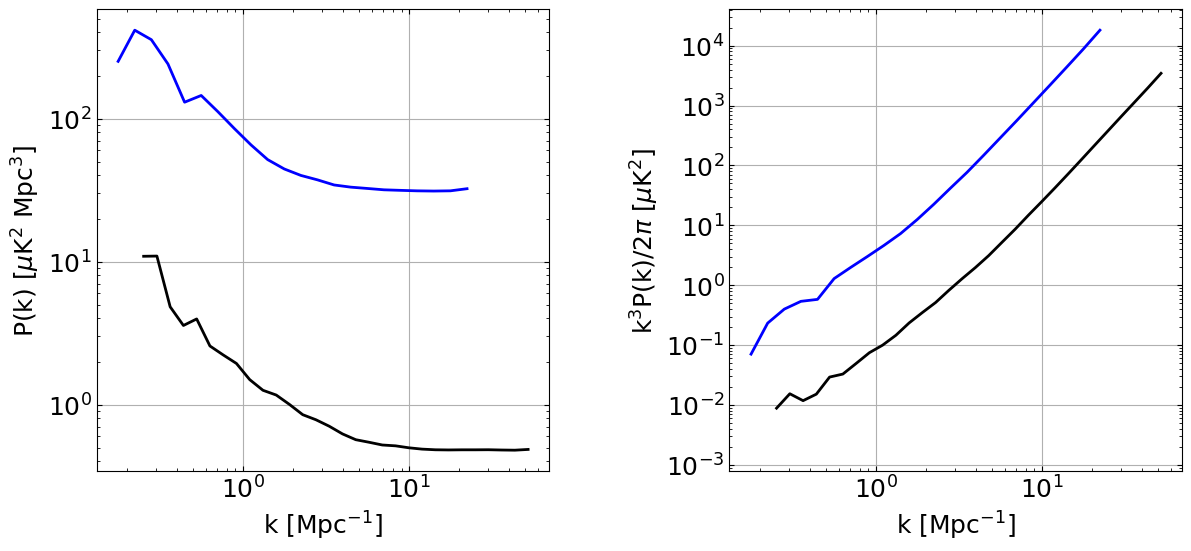

In [77]:
ps = grid.power_spectrum(in_place=False,normalize=True)

# Spherical average
bins = np.logspace(-3,3,101)
bin_centers = np.logspace(-2.95,2.95,100)
_,ps1d = ps.spherical_average(ax=[0,1,2],bins=bins)
ps1d1 = ps1d[:,0] / side_length**3                           # Normalize by volume
k1 = 2*np.pi * bin_centers

# Plot the results
fig,ax = plt.subplots(1,2,figsize=(14,6),sharex=True)
fig.subplots_adjust(wspace=.4)
ax[0].set(xlabel='k [Mpc$^{-1}$]',ylabel='P(k) [$\mu$K$^2$ Mpc$^{3}$]',xscale='log',yscale='log')
ax[0].grid()
ax[0].plot(k2,ps1d2,lw=2,color='k')
ax[0].plot(k1,ps1d1,lw=2,color='blue')
ax[1].set(xlabel='k [Mpc$^{-1}$]',ylabel='k$^3$P(k)/2$\pi$ [$\mu$K$^2$]',xscale='log',yscale='log')
ax[1].plot(k2,k2**3/2/np.pi**2*ps1d2,lw=2,color='k')
ax[1].plot(k1,k1**3/2/np.pi**2*ps1d1,lw=2,color='blue')
ax[1].grid()
plt.show()